# Rademacher Anti-Serum (RAS) Protocol

**Docker image**: `ml4t`

**Book Reference**: Chapter 16, §16.7 - strategy-level overfitting control.

This notebook demonstrates the Rademacher Anti-Serum (RAS) protocol for
backtest overfitting detection using `ml4t-diagnostic`.

**Learning objectives**

- Estimate empirical Rademacher complexity for a finite strategy class.
- Apply RAS bounds in native-frequency units before annualizing the result.
- Contrast the assumptions and outputs of RAS and the Deflated Sharpe Ratio (DSR).
- Interpret RAS diagnostics for Sharpe ratios, information coefficients, and parameter grids.

**Prerequisites**: Familiarity with Sharpe ratios, information coefficients,
multiple testing, and NumPy array operations.

## RAS and DSR Provide Complementary Diagnostics

| Aspect | DSR | RAS |
|--------|-----|-----|
| Correlation | Raw trial count needs a separate effective-trials adjustment | Uses the candidate performance matrix |
| Assumption | Asymptotic Sharpe sampling approximation | Finite-sample sub-Gaussian lower bound |
| Output | Tail probability above a selection benchmark | Lower performance bound |
| Computation | Closed form after trial statistics are known | Monte Carlo complexity estimate |

## Key Concepts

- **Rademacher Complexity (R̂)**: Measures a candidate class's capacity to fit random signs
- **Massart's Bound**: A scale-aware upper bound for a finite candidate class
- **RAS Adjustment**: θ ≥ θ̂ - 2R̂ - estimation_error
- **Data Snooping Bias**: Selection bias from picking the "best" strategy

## References

- Paleologo, G. (2024). "Elements of Quantitative Investing", Chapter 8
- Mohri, Rostamizadeh & Talwalkar (2018). "Foundations of Machine Learning"

In [1]:
"""Demonstrate Rademacher complexity adjustments for strategy selection."""

import numpy as np

# Visualization
import plotly.graph_objects as go

# ml4t-diagnostic RAS functions
from ml4t.diagnostic.evaluation.stats import (
    rademacher_complexity,
    ras_ic_adjustment,
    ras_sharpe_adjustment,
)
from plotly.subplots import make_subplots
from scipy import stats

from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
# Production defaults - Papermill injects overrides after this cell
N_SIMULATIONS = 5000
SEED = 42

In [3]:
set_global_seeds(SEED)

In [4]:
EULER_MASCHERONI = 0.5772156649

### Deflated Sharpe Ratio Baseline

We include a self-contained DSR helper so we can compare its
output against the RAS adjustment on the same data.

In [5]:
def _expected_max_sharpe(variance_trials: float, n_trials: int) -> float:
    """Expected maximum trial Sharpe in its native sampling frequency."""
    if n_trials <= 1 or variance_trials <= 0:
        return 0.0
    z1 = stats.norm.ppf(1.0 - (1.0 / n_trials))
    z2 = stats.norm.ppf(1.0 - (np.exp(-1.0) / n_trials))
    weight = (1.0 - EULER_MASCHERONI) * z1 + EULER_MASCHERONI * z2
    return float(np.sqrt(variance_trials) * weight)

The formatter keeps native-frequency computation separate from annualized
presentation. This prevents the DSR benchmark and observed Sharpe from being
compared in different units.

In [6]:
def _format_dsr_result(
    probability: float,
    z_score: float,
    expected_max: float,
    annualizer: float,
    observed_sharpe: float,
    confidence_level: float,
) -> dict[str, float | bool]:
    """Expose DSR components on the annualized scale used by the notebook."""
    expected_max_annual = expected_max * annualizer
    return {
        "dsr": probability,
        "z_score": z_score,
        "p_value": 1.0 - probability,
        "expected_max_sharpe": expected_max_annual,
        "adjusted_sharpe": observed_sharpe - expected_max_annual,
        "is_significant": probability >= confidence_level,
    }

The local DSR helper makes that unit conversion explicit. It is an educational
baseline for the fixed-input comparison below, not a replacement for the
library implementation.

In [7]:
def deflated_sharpe_ratio(
    observed_sharpe: float,
    skewness: float = 0.0,
    kurtosis: float = 3.0,
    n_samples: int = 252,
    n_trials: int = 1,
    variance_trials: float = 0.0,
    confidence_level: float = 0.95,
    return_format: str = "probability",
    return_components: bool = False,
    periods_per_year: int = 252,
) -> float | dict[str, float | bool]:
    """Compute DSR from annualized Sharpe statistics and native observations."""
    annualizer = np.sqrt(periods_per_year)
    observed_native = observed_sharpe / annualizer
    variance_native = max(variance_trials, 0.0) / periods_per_year
    expected_max = _expected_max_sharpe(variance_native, n_trials)
    variance = 1.0 - skewness * observed_native + ((kurtosis - 1.0) / 4.0) * observed_native**2
    denominator = np.sqrt(max(variance, 1e-12))
    z_score = (observed_native - expected_max) * np.sqrt(max(n_samples - 1, 1)) / denominator
    probability = float(stats.norm.cdf(z_score))
    components = _format_dsr_result(
        probability, float(z_score), expected_max, annualizer, observed_sharpe, confidence_level
    )
    if return_components:
        return components
    if return_format == "probability":
        return probability
    if return_format == "zscore":
        return float(z_score)
    if return_format == "adjusted_sharpe":
        return float(components["adjusted_sharpe"])
    if return_format == "p_value":
        return float(components["p_value"])
    raise ValueError(f"Unknown return_format: {return_format}")

### Library Convention Check

The helper exposes the paper's equation using the observed Sharpe in the
non-normal variance term. The library evaluates variance at the adjusted
benchmark and supports additional corrections, so the values are a
fixed-input comparison rather than an equivalence assertion.

In [8]:
from ml4t.diagnostic.evaluation.stats import deflated_sharpe_ratio_from_statistics

_local = deflated_sharpe_ratio(
    observed_sharpe=1.0,
    skewness=0.0,
    kurtosis=3.0,
    n_samples=504,
    n_trials=100,
    variance_trials=0.3,
    return_format="probability",
)
_lib = deflated_sharpe_ratio_from_statistics(
    observed_sharpe=1.0 / np.sqrt(252),
    n_samples=504,
    n_trials=100,
    variance_trials=0.3 / 252,
    skewness=0.0,
    excess_kurtosis=0.0,
)
print(f"Local DSR: {_local:.4f} | Library DSR: {_lib.probability:.4f}")
print("In practice, use: from ml4t.diagnostic.evaluation.stats import deflated_sharpe_ratio")

Local DSR: 0.2929 | Library DSR: 0.1022
In practice, use: from ml4t.diagnostic.evaluation.stats import deflated_sharpe_ratio


The displayed library probability is independent of the MinTRL field also
carried by the result object. This notebook never reads or displays MinTRL.

## 1. Understanding Rademacher Complexity

Rademacher complexity measures how well a set of strategies can fit random noise:

$$\hat{R} = \mathbb{E}_\epsilon\left[\max_n \frac{\epsilon^T x^n}{T}\right]$$

Where $\epsilon$ is a Rademacher vector (random ±1 with probability 0.5).

In [9]:
def normalize_column_norms(values: np.ndarray) -> np.ndarray:
    """Normalize each candidate path to Euclidean norm sqrt(T)."""
    target_norm = np.sqrt(values.shape[0])
    norms = np.linalg.norm(values, axis=0)
    return values * (target_norm / np.maximum(norms, 1e-12))

Massart's finite-class bound depends on the largest candidate-path norm.
Retaining that scale is essential when the input matrix is not normalized.

In [10]:
def massart_upper_bound(performance: np.ndarray) -> float:
    """Return Massart's finite-class bound in the matrix's native units."""
    n_periods, n_candidates = performance.shape
    max_norm = np.linalg.norm(performance, axis=0).max()
    return float(max_norm * np.sqrt(2 * np.log(n_candidates)) / n_periods)

In [11]:
# Compare abstract candidate classes on a common column-norm scale.
rng = np.random.default_rng(SEED)

T = 252  # 1 year daily
N = 100  # 100 strategies

X_uncorrelated = normalize_column_norms(rng.standard_normal((T, N)))
base_strategy = rng.standard_normal(T)
correlated_noise = rng.standard_normal((T, N)) * 0.1
X_correlated = normalize_column_norms(base_strategy[:, None] + correlated_noise)
X_identical = normalize_column_norms(np.repeat(base_strategy[:, None], N, axis=1))

R_uncorrelated = rademacher_complexity(X_uncorrelated, N_SIMULATIONS, SEED)
R_correlated = rademacher_complexity(X_correlated, N_SIMULATIONS, SEED)
R_identical = rademacher_complexity(X_identical, N_SIMULATIONS, SEED)

massart_bound = massart_upper_bound(X_uncorrelated)

print("=== Rademacher Complexity Analysis ===")
print(f"\nNumber of strategies: {N}")
print(f"Sample size: {T}")
print(f"\nMassart's bound (uncorrelated): {massart_bound:.4f}")
print("\nEmpirical R̂:")
print(f"  Uncorrelated: {R_uncorrelated:.4f} ({R_uncorrelated / massart_bound:.1%} of bound)")
print(f"  Correlated:   {R_correlated:.4f} ({R_correlated / massart_bound:.1%} of bound)")
print(f"  Identical:    {R_identical:.4f} ({R_identical / massart_bound:.1%} of bound)")

=== Rademacher Complexity Analysis ===

Number of strategies: 100
Sample size: 252

Massart's bound (uncorrelated): 0.1912

Empirical R̂:
  Uncorrelated: 0.1575 (82.4% of bound)
  Correlated:   0.0166 (8.7% of bound)
  Identical:    0.0008 (0.4% of bound)


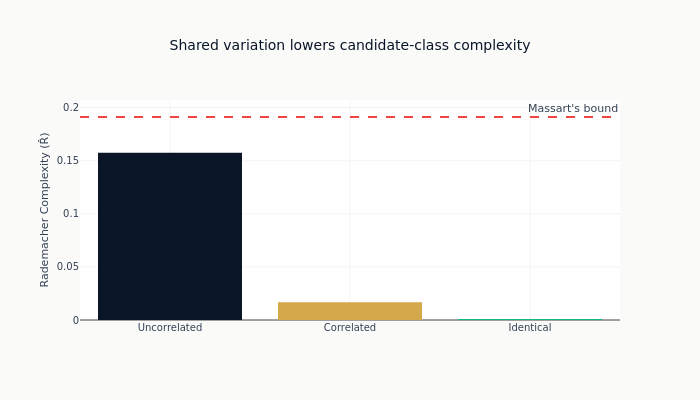

In [12]:
# Compare empirical complexities against the shared normalized bound.
fig = go.Figure()

strategies = ["Uncorrelated", "Correlated", "Identical"]
R_values = [R_uncorrelated, R_correlated, R_identical]

fig.add_trace(
    go.Bar(
        x=strategies,
        y=R_values,
        marker_color=[COLORS["blue"], COLORS["amber"], COLORS["positive"]],
        name="R̂",
    )
)

fig.add_hline(
    y=massart_bound,
    line_dash="dash",
    line_color=COLORS["negative"],
    annotation_text="Massart's bound",
)

fig.update_layout(
    title="Shared variation lowers candidate-class complexity",
    yaxis_title="Rademacher Complexity (R̂)",
    height=400,
)

fig.show()

With candidate count, sample size, and column norms fixed, greater shared
variation lowers the empirical complexity of this constructed class. RAS can
therefore distinguish a tightly related parameter family from the same number
of nearly independent trials.

## 2. RAS Adjustment for Sharpe Ratios

Formula (Procedure 8.2 in Paleologo):

$$\theta_n \geq \hat{\theta}_n - 2\hat{R} - 3\sqrt{\frac{2\log(2/\delta)}{T}} - \sqrt{\frac{2\log(2N/\delta)}{T}}$$

Every term in this bound uses per-period, volatility-standardized return
units. We annualize the observed estimate and its lower bound only for display.

In [13]:
# Simulate a correlated candidate return matrix.
rng = np.random.default_rng(SEED)

T = 504  # 2 years
N = 500  # 500 strategy variants

# Generate returns matrix
# Strategies are correlated (parameter sweep of similar strategy)
base_returns = rng.standard_normal(T) * 0.01 + 0.0002
strategy_returns = base_returns[:, None] + rng.standard_normal((T, N)) * 0.005

# Express each path in per-period Sharpe units without removing its mean.
return_volatility = np.std(strategy_returns, axis=0, ddof=1)
standardized_returns = strategy_returns / return_volatility
observed_sharpe_native = np.mean(standardized_returns, axis=0)
observed_sharpe = observed_sharpe_native * np.sqrt(252)

print("=== Strategy Universe ===")
print(f"\nStrategies: {N}")
print(f"Sample size: {T} days")
print("\nObserved Sharpe Ratios:")
print(f"  Max: {np.max(observed_sharpe):.3f}")
print(f"  Mean: {np.mean(observed_sharpe):.3f}")
print(f"  Min: {np.min(observed_sharpe):.3f}")

=== Strategy Universe ===

Strategies: 500
Sample size: 504 days

Observed Sharpe Ratios:
  Max: 1.281
  Mean: 0.104
  Min: -0.950


In [14]:
# Compute complexity in the same per-period Sharpe units as the bound.
R_hat = rademacher_complexity(standardized_returns, N_SIMULATIONS, SEED)
massart_returns = massart_upper_bound(standardized_returns)

print("\n=== Rademacher Analysis ===")
print(f"\nR̂: {R_hat:.4f}")
print(f"Scale-aware Massart bound: {massart_returns:.4f}")
print(f"Ratio: {R_hat / massart_returns:.1%}")


=== Rademacher Analysis ===

R̂: 0.0631
Scale-aware Massart bound: 0.1574
Ratio: 40.1%


In [15]:
# Apply the bound in native units, then annualize its result for display.
adjusted_sharpe_native = ras_sharpe_adjustment(
    observed_sharpe=observed_sharpe_native,
    complexity=R_hat,
    n_samples=T,
    n_strategies=N,
    delta=0.05,  # 95% confidence
)
adjusted_sharpe = adjusted_sharpe_native * np.sqrt(252)

# Compare positive point estimates with positive RAS lower bounds.
n_positive_raw = np.sum(observed_sharpe > 0)
n_positive_ras = np.sum(adjusted_sharpe > 0)

print("\n=== RAS Adjustment Results ===")
print("\nPositive Sharpe estimates:")
print(f"  Observed: {n_positive_raw}/{N} ({n_positive_raw / N:.1%})")
print(f"  RAS lower bound: {n_positive_ras}/{N} ({n_positive_ras / N:.1%})")

print("\nBest strategy:")
best_idx = np.argmax(observed_sharpe)
print(f"  Observed SR: {observed_sharpe[best_idx]:.3f}")
print(f"  Adjusted SR: {adjusted_sharpe[best_idx]:.3f}")
print(f"  Adjustment: {observed_sharpe[best_idx] - adjusted_sharpe[best_idx]:.3f}")


=== RAS Adjustment Results ===

Positive Sharpe estimates:
  Observed: 311/500 (62.2%)
  RAS lower bound: 0/500 (0.0%)

Best strategy:
  Observed SR: 1.281
  Adjusted SR: -9.632
  Adjustment: 10.913


In [16]:
# Build the observed-versus-bound panel.
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["RAS lowers Sharpe", "Bounds shift left"],
)

fig.add_trace(
    go.Scatter(
        x=observed_sharpe,
        y=adjusted_sharpe,
        mode="markers",
        marker=dict(
            size=5,
            color=np.where(adjusted_sharpe > 0, COLORS["positive"], COLORS["negative"]),
            opacity=0.5,
        ),
        name="Candidates",
    ),
    row=1,
    col=1,
)

sr_range = [np.min(observed_sharpe), np.max(observed_sharpe)]
_ = fig.add_trace(
    go.Scatter(
        x=sr_range,
        y=sr_range,
        mode="lines",
        line=dict(dash="dash", color=COLORS["neutral"]),
        name="No adjustment",
    ),
    row=1,
    col=1,
)

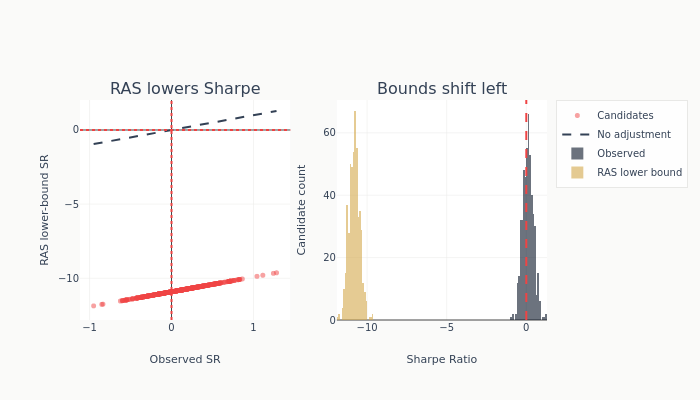

In [17]:
# Add the distribution panel and reference lines.
fig.add_trace(
    go.Histogram(
        x=observed_sharpe,
        name="Observed",
        marker_color=COLORS["blue"],
        opacity=0.6,
        nbinsx=30,
    ),
    row=1,
    col=2,
)
fig.add_trace(
    go.Histogram(
        x=adjusted_sharpe,
        name="RAS lower bound",
        marker_color=COLORS["amber"],
        opacity=0.6,
        nbinsx=30,
    ),
    row=1,
    col=2,
)

fig.add_hline(y=0, line_dash="dot", line_color=COLORS["negative"], row=1, col=1)
fig.add_vline(x=0, line_dash="dot", line_color=COLORS["negative"], row=1, col=1)
fig.add_vline(x=0, line_dash="dash", line_color=COLORS["negative"], row=1, col=2)

fig.update_layout(height=400, barmode="overlay")
fig.update_xaxes(title_text="Observed SR", row=1, col=1)
fig.update_yaxes(title_text="RAS lower-bound SR", row=1, col=1)
fig.update_xaxes(title_text="Sharpe Ratio", row=1, col=2)
fig.update_yaxes(title_text="Candidate count", row=1, col=2)

fig.show()

The lower-bound distribution shifts left of the point estimates because RAS
charges for both class complexity and finite-sample uncertainty. A promising
selected Sharpe is therefore not enough: the lower bound must clear the
decision hurdle for the evidence to survive the search adjustment.

## 3. RAS vs DSR Comparison

Compare the two multiple testing corrections.

In [18]:
# Compare RAS and DSR
best_sharpe = np.max(observed_sharpe)
variance_trials = np.var(observed_sharpe, ddof=1)

# DSR analysis
dsr_result = deflated_sharpe_ratio(
    observed_sharpe=best_sharpe,
    n_trials=N,
    variance_trials=variance_trials,
    n_samples=T,
    return_components=True,
)

# RAS analysis (best strategy)
ras_adjusted_best = adjusted_sharpe[best_idx]

print("=== RAS vs DSR Comparison ===")
print(f"\nBest observed Sharpe: {best_sharpe:.3f}")
print("\nDSR Analysis:")
print(f"  Expected max (E[max]): {dsr_result['expected_max_sharpe']:.3f}")
print(f"  DSR probability: {dsr_result['dsr']:.3f}")
print(f"  p-value: {dsr_result['p_value']:.4f}")

print("\nRAS Analysis:")
print(f"  Rademacher complexity: {R_hat:.4f}")
print(f"  Adjusted SR: {ras_adjusted_best:.3f}")
print(f"  Adjustment magnitude: {best_sharpe - ras_adjusted_best:.3f}")
print(f"  Positive 95% lower bound: {'Yes' if ras_adjusted_best > 0 else 'No'}")

=== RAS vs DSR Comparison ===

Best observed Sharpe: 1.281

DSR Analysis:
  Expected max (E[max]): 1.041
  DSR probability: 0.632
  p-value: 0.3677

RAS Analysis:
  Rademacher complexity: 0.0631
  Adjusted SR: -9.632
  Adjustment magnitude: 10.913
  Positive 95% lower bound: No


DSR and RAS answer different questions. DSR reports a tail probability relative
to a selection benchmark, while RAS reports a finite-sample lower bound. Reading
both prevents a probability from being mistaken for a guaranteed performance
floor.

## 4. RAS for Information Coefficients

In [19]:
# Simulate bounded per-period IC observations.
ic_rng = np.random.default_rng(123)

T = 252  # 1 year
N = 50  # 50 signals

# Generate IC matrix (T observations, N signals)
# Most signals are noise, a few have true predictive power
n_true = 5
true_ic = 0.03  # True IC for real signals

ic_matrix = ic_rng.uniform(-0.05, 0.05, size=(T, N))
ic_matrix[:, :n_true] += true_ic

observed_ic = np.mean(ic_matrix, axis=0)

print("=== Signal IC Analysis ===")
print(f"\nSignals: {N}")
print(f"True signals: {n_true}")
print(f"True IC: {true_ic}")
print("\nObserved mean IC:")
print(f"  Max: {np.max(observed_ic):.4f}")
print(f"  Mean: {np.mean(observed_ic):.4f}")

=== Signal IC Analysis ===

Signals: 50
True signals: 5
True IC: 0.03

Observed mean IC:
  Max: 0.0301
  Mean: 0.0027


In [20]:
# Compute complexity in the same bounded IC units used by the adjustment.
R_hat_ic = rademacher_complexity(ic_matrix, N_SIMULATIONS, SEED)

# Apply RAS adjustment for IC
adjusted_ic = ras_ic_adjustment(
    observed_ic=observed_ic,
    complexity=R_hat_ic,
    n_samples=T,
    delta=0.05,
    kappa=0.1,  # Max IC bound
)

# Compare candidates above a 1% practical hurdle.
n_above_raw = np.sum(observed_ic > 0.01)
n_above_ras = np.sum(adjusted_ic > 0.01)

print("\n=== RAS Adjustment for IC ===")
print(f"\nR̂ (IC): {R_hat_ic:.4f}")
print("\nSignals above the 1% IC hurdle:")
print(f"  Observed: {n_above_raw}/{N}")
print(f"  RAS lower bound: {n_above_ras}/{N}")

# Check true signal detection
true_detected_raw = np.sum(observed_ic[:n_true] > 0.01)
true_detected_ras = np.sum(adjusted_ic[:n_true] > 0.01)
false_positives_raw = np.sum(observed_ic[n_true:] > 0.01)
false_positives_ras = np.sum(adjusted_ic[n_true:] > 0.01)

print("\nTrue signal detection:")
print(f"  Raw: {true_detected_raw}/{n_true}")
print(f"  RAS: {true_detected_ras}/{n_true}")
print("\nNull signals above the hurdle:")
print(f"  Raw: {false_positives_raw}/{N - n_true}")
print(f"  RAS: {false_positives_ras}/{N - n_true}")


=== RAS Adjustment for IC ===

R̂ (IC): 0.0042

Signals above the 1% IC hurdle:
  Observed: 5/50
  RAS lower bound: 0/50

True signal detection:
  Raw: 5/5
  RAS: 0/5

Null signals above the hurdle:
  Raw: 0/45
  RAS: 0/45


The raw hurdle identifies the deliberately shifted signals in this bounded
construction, but the RAS lower bounds remain more conservative. This is a
diagnostic of finite-sample search uncertainty, not a claim that the synthetic
signals would trade profitably.

## 5. Synthetic Daily Parameter Grid

The labels resemble an ETF momentum sweep, but this example does not load ETF
prices, compute momentum ranks, or rebalance a portfolio. It isolates how RAS
treats a correlated daily candidate matrix; it is not a case-study result.

In [21]:
# Create labels for an illustrative daily parameter grid.
daily_rng = np.random.default_rng(SEED)

T = 504  # 2 years daily

# Parameter grid
lookback_periods = [5, 10, 21, 42, 63, 126, 252]
holding_periods = [1, 5, 10, 21, 42]
n_top_assets = [1, 2, 3, 5]

N = len(lookback_periods) * len(holding_periods) * len(n_top_assets)
print(f"Parameter combinations: {N}")

# Generate correlated synthetic returns independent of the parameter labels.
base_returns = daily_rng.standard_normal(T) * 0.01 + 0.0001

strategy_returns = []
param_labels = []

for lb in lookback_periods:
    for hp in holding_periods:
        for top_n in n_top_assets:
            param_noise = daily_rng.standard_normal(T) * 0.003
            returns = base_returns + param_noise
            strategy_returns.append(returns)
            param_labels.append(f"LB{lb}_HP{hp}_N{top_n}")

strategy_returns = np.column_stack(strategy_returns)

# Compute native and annualized Sharpe estimates from the same standardized paths.
daily_volatility = np.std(strategy_returns, axis=0, ddof=1)
standardized_daily = strategy_returns / daily_volatility
daily_sharpe_native = np.mean(standardized_daily, axis=0)
sharpe_ratios = daily_sharpe_native * np.sqrt(252)

Parameter combinations: 140


In [22]:
# Apply RAS in per-period Sharpe units.
R_hat_daily = rademacher_complexity(standardized_daily, N_SIMULATIONS, SEED)
massart_daily = massart_upper_bound(standardized_daily)

adjusted_daily_native = ras_sharpe_adjustment(
    observed_sharpe=daily_sharpe_native,
    complexity=R_hat_daily,
    n_samples=T,
    n_strategies=N,
    delta=0.05,
)
adjusted_sharpe_daily = adjusted_daily_native * np.sqrt(252)

print("=== Synthetic Daily Parameter Grid ===")
print(f"\nStrategies tested: {N}")
print(f"R̂: {R_hat_daily:.4f}")
print(f"Scale-aware Massart bound: {massart_daily:.4f}")

# Best strategy
best_idx = np.argmax(sharpe_ratios)
print(f"\nBest parameters: {param_labels[best_idx]}")
print(f"  Observed SR: {sharpe_ratios[best_idx]:.3f}")
print(f"  RAS lower-bound SR: {adjusted_sharpe_daily[best_idx]:.3f}")

# Compare the same practical hurdle before and after adjustment.
n_above_raw = np.sum(sharpe_ratios > 0.5)
n_above_ras = np.sum(adjusted_sharpe_daily > 0.5)
print("\nStrategies with SR > 0.5:")
print(f"  Observed: {n_above_raw}")
print(f"  RAS lower bound: {n_above_ras}")

=== Synthetic Daily Parameter Grid ===

Strategies tested: 140
R̂: 0.0356
Scale-aware Massart bound: 0.1401

Best parameters: LB10_HP42_N3
  Observed SR: 0.691
  RAS lower-bound SR: -9.139

Strategies with SR > 0.5:
  Observed: 2
  RAS lower bound: 0


The best label is selected from correlated synthetic paths, so its point
estimate inherits search optimism. The lower bound asks whether the selected
candidate remains attractive after charging for the whole candidate class.

## 6. Synthetic Hourly Parameter Grid

The labels resemble funding-strategy controls, but the example does not load
funding rates, form positions, or calculate funding cash flows. The hourly
paths are synthetic and illustrate the adjustment only.

In [23]:
# Create labels for an illustrative hourly parameter grid.
hourly_rng = np.random.default_rng(789)

T = 24 * 90  # 90 days hourly

# Parameter grid for funding rate strategy
lookback_hours = [4, 8, 24, 48, 72]
threshold_pcts = [0.01, 0.02, 0.05, 0.1]
position_sizes = [0.25, 0.5, 0.75, 1.0]

N = len(lookback_hours) * len(threshold_pcts) * len(position_sizes)
print(f"Hourly strategy variants: {N}")

# Generate correlated synthetic hourly returns.
base_returns = hourly_rng.standard_normal(T) * 0.002 + 0.00005

hourly_returns = base_returns[:, None] + hourly_rng.standard_normal((T, N)) * 0.001

# Compute native and annualized Sharpe estimates from the standardized paths.
hourly_annualizer = np.sqrt(24 * 365)
hourly_volatility = np.std(hourly_returns, axis=0, ddof=1)
standardized_hourly = hourly_returns / hourly_volatility
hourly_sharpe_native = np.mean(standardized_hourly, axis=0)
hourly_sharpe = hourly_sharpe_native * hourly_annualizer

Hourly strategy variants: 80


In [24]:
# Apply RAS in per-period Sharpe units.
R_hat_hourly = rademacher_complexity(standardized_hourly, N_SIMULATIONS, SEED)
massart_hourly = massart_upper_bound(standardized_hourly)

adjusted_hourly_native = ras_sharpe_adjustment(
    observed_sharpe=hourly_sharpe_native,
    complexity=R_hat_hourly,
    n_samples=T,
    n_strategies=N,
    delta=0.05,
)
adjusted_hourly = adjusted_hourly_native * hourly_annualizer

print("\n=== Synthetic Hourly Parameter Grid ===")
print(f"\nR̂: {R_hat_hourly:.4f}")
print(f"Scale-aware Massart bound: {massart_hourly:.4f}")
print(f"\nBest observed SR: {np.max(hourly_sharpe):.2f}")
print(f"Best RAS lower-bound SR: {np.max(adjusted_hourly):.2f}")
print(f"\nLower bounds above SR 1.0: {np.sum(adjusted_hourly > 1.0)}/{N}")


=== Synthetic Hourly Parameter Grid ===

R̂: 0.0229
Scale-aware Massart bound: 0.0637

Best observed SR: 2.02
Best RAS lower-bound SR: -26.77

Lower bounds above SR 1.0: 0/80


More observations do not eliminate the multiple-testing charge when the
candidate set can still align with noise. The hourly example reinforces that
annualization belongs after the native-frequency bound, not inside its inputs.

## References

- Paleologo, G. (2024). "Elements of Quantitative Investing", Chapter 8
- Mohri, Rostamizadeh & Talwalkar (2018). "Foundations of Machine Learning"
- GitHub: https://github.com/RSv618/rademacher-anti-serum

## Findings and Next Steps

- Rademacher complexity measures the realized capacity of the candidate matrix,
  so dependence among trials enters directly rather than through a raw count.
- RAS must be computed from per-period volatility-standardized returns without
  demeaning; annualization is a presentation step applied afterward.
- DSR supplies a selection-adjusted probability, while RAS supplies a lower
  performance bound. They are complementary, not interchangeable.
- A strong point estimate can fail a lower-bound hurdle once class complexity
  and sampling uncertainty are included.

**Limitations.** These examples use synthetic IID paths to isolate the formulas.
Real trading returns often exhibit serial dependence and regime changes, which
require a dependence-aware resampling or concentration design. The examples
also omit transaction costs and portfolio construction.

This notebook implements the strategy-level overfitting controls discussed in
Chapter 16, §16.7. Continue to `14_cost_sensitivity` to test whether a selected
strategy remains viable when execution-cost assumptions change.

## RAS API

```python
from ml4t.diagnostic.evaluation.stats import (
    rademacher_complexity,
    ras_sharpe_adjustment,
    ras_ic_adjustment,
)

# Step 1: Standardize without demeaning, then compute native estimates
standardized = candidate_returns / candidate_returns.std(axis=0, ddof=1)
observed_native = standardized.mean(axis=0)
R_hat = rademacher_complexity(standardized, n_simulations=5000)

# Step 2: Apply RAS adjustment
adjusted_native = ras_sharpe_adjustment(
    observed_native,
    complexity=R_hat,
    n_samples=T,
    n_strategies=N,
    delta=0.05
)

# Step 3: Annualize only after applying the native-unit bound
adjusted_sharpe = adjusted_native * np.sqrt(periods_per_year)
positive_lower_bound = adjusted_sharpe > 0
```

## When to Use RAS vs DSR

| Scenario | Use |
|----------|-----|
| Independent, low-correlation trials | Compare both and state each assumption |
| Correlated parameter sweep | Use RAS or estimate effective trials before DSR |
| Quick diagnostic | Use DSR, with the raw-trial-count caveat |
| Reported research result | Report the diagnostic, inputs, and assumptions |